# 01 — Lazy Evaluation & the Spark DAG

**Concept:** Spark builds a logical plan (DAG) as you chain transformations, but executes *nothing* until you call an action.  
**Why it matters for interviews:** Every question about performance, shuffles, or caching starts here.

## What you will observe
1. Transformations are free — they just extend the DAG.
2. Actions trigger a job; you can see exactly what Spark plans via `.explain()`.
3. Wide transformations (shuffles) introduce stage boundaries — visible in the plan.
4. Classic interview gotchas: re-triggering jobs accidentally.

In [1]:
import sys
import os
from pathlib import Path
import time

sys.path.append(str(Path().absolute().parent))

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("01-lazy-evaluation")
    .config("spark.sql.adaptive.enabled", "true")
    # Arrow-based pandas↔Spark transfer: createDataFrame(pandas_df) sends data
    # to the JVM as an Arrow IPC buffer — no Python worker processes needed.
    # Without this, Spark falls back to applySchemaToPythonRDD (Python pickle),
    # which spawns workers and crashes on Windows + Spark 4.x.
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.python.worker.faulthandler.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} — UI: http://localhost:4040")
print(f"Worker Python: {sys.executable}")
print(f"Arrow enabled: {spark.conf.get('spark.sql.execution.arrow.pyspark.enabled')}")

# spark.range(5).show()
# print("smoke test passed")

Spark 4.1.1 — UI: http://localhost:4040
Worker Python: c:\Users\krivg\spark-bq\.venv\Scripts\python.exe
Arrow enabled: true


In [2]:
spark.conf.get("spark.sql.adaptive.enabled")

'true'

In [3]:
# Default number of shuffle partitions is 200, which is excessive for local testing.
spark.conf.get("spark.sql.shuffle.partitions")

'200'

## 1. Build sample data

We use a hard-coded list so there is no I/O noise — the focus is on the execution model, not data sources.

In [ ]:
import pandas as pd
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, DoubleType

# Keep rows as a Python list — reused in section 6 (JSON schema-inference demo)
rows = [
    (1,  "alice",  "eng",    95000.0),
    (2,  "bob",    "sales",  72000.0),
    (3,  "carol",  "eng",   105000.0),
    (4,  "dave",   "sales",  68000.0),
    (5,  "eve",    "eng",    88000.0),
    (6,  "frank",  "hr",     61000.0),
    (7,  "grace",  "hr",     63000.0),
    (8,  "heidi",  "eng",   112000.0),
    (9,  "ivan",   "sales",  74000.0),
    (10, "judy",   "eng",    99000.0),
]

schema = StructType([
    StructField("id",     IntegerType(), False),
    StructField("name",   StringType(),  True),
    StructField("dept",   StringType(),  True),
    StructField("salary", DoubleType(),  True),
])

pdf = pd.DataFrame(rows, columns=["id", "name", "dept", "salary"])

# With spark.sql.execution.arrow.pyspark.enabled=true, Spark transfers the
# pandas DataFrame to the JVM as an Arrow IPC buffer — no Python worker processes.
# The physical plan will show LocalTableScan instead of applySchemaToPythonRDD.
df = spark.createDataFrame(pdf, schema=schema)

print("df created — check plan to confirm Arrow path (no applySchemaToPythonRDD):")
df.explain()
print(f"Partitions: {df.rdd.getNumPartitions()}")

df created — check plan to confirm Arrow path (no applySchemaToPythonRDD):
== Physical Plan ==
LocalTableScan [id#0, name#1, dept#2, salary#3]


Partitions: 8


## 2. Chaining transformations — building the DAG

Each call below returns a *new* DataFrame object. Nothing runs. Spark just appends a node to the logical plan.

In [ ]:
# NARROW transformation: filter does not require data movement between partitions.
step1 = df.filter(F.col("salary") > 70000)

# NARROW: withColumn adds a computed column per-row, same partition.
step2 = step1.withColumn("salary_k", F.col("salary") / 1000)

# WIDE transformation: groupBy requires a shuffle — all rows for the same dept
# key must land on the same partition. This is where a stage boundary appears.
step3 = step2.groupBy("dept").agg(
    F.count("*").alias("headcount"), # count("*") -> count rows, not just non-null salaries
    F.avg("salary_k").alias("avg_salary_k"),
)

# NARROW: orderBy on the result (technically triggers another shuffle for global sort).
result = step3.orderBy("avg_salary_k", ascending=False)

print("Four transformation steps defined.")
print("Check the Spark UI Jobs tab — zero jobs should have run so far.")

## 3. Inspect the plan with `.explain()` — *before* any action

`.explain()` itself is not an action (it does not compute data). It prints the optimized physical plan Catalyst produced from the logical plan you built above.

**What to look for:**
- `Exchange` nodes = shuffle = stage boundary
- `Project` / `Filter` = narrow, pushed down as far as possible
- `HashAggregate` (partial) → `Exchange` → `HashAggregate` (final) = the classic 2-phase aggregation pattern

#### Parsed Logical plan is a unresolved plan that extracted from the query
#### Analyzed logical plans transforms which translates unresolvedAttribute and unresolvedRelation into fully typed objects
#### The optimized logical plan transforms through a set of optimization rules, resulting in the physical plan.

In [ ]:
print("=" * 60)
print("SIMPLE (default) plan:")
print("=" * 60)
result.explain()

print("\n" + "=" * 60)
print("EXTENDED plan — logical + optimized + physical:")
print("=" * 60)
result.explain(mode="extended")

In [ ]:
# FORMATTED mode is most readable for stage-boundary analysis
print("FORMATTED plan — tree with operators and metrics:")
result.explain(mode="formatted")

### Mapping the formatted plan to the SQL tab

`explain(mode="formatted")` and the Spark UI SQL tab show the same physical plan. Use this reference to translate between them:

| `explain()` node | SQL tab label | What it means for debugging |
|---|---|---|
| `AdaptiveSparkPlan isFinalPlan=false` | Adaptive plan wrapper | AQE will modify this plan at runtime — not final yet |
| `AdaptiveSparkPlan isFinalPlan=true` | Adaptive plan wrapper (finalized) | Post-execution — actual AQE decisions applied |
| `Exchange hashpartitioning(dept, 200)` | Exchange node (shuffle icon) | **Stage boundary** — rows move between executors by hash of `dept` |
| `Exchange rangepartitioning(col, N)` | Exchange node | **Stage boundary** for global sort — rows moved into range buckets |
| `AQEShuffleRead` | AQEShuffleRead | AQE coalesced shuffle partitions post-execution (shows actual count) |
| `HashAggregate(partial)` | HashAggregate | Per-partition partial aggregation before the shuffle |
| `HashAggregate(final)` | HashAggregate | Post-shuffle merge of partial aggregates |
| `Filter (salary > 70000)` | Filter | Predicate evaluation — check its position relative to Exchange |
| `LocalTableScan [dept, salary]` | LocalTableScan | Reads from in-memory DataFrame (created via `createDataFrame`) |
| `BroadcastHashJoin` | BroadcastHashJoin | Small table broadcast — no shuffle on small side |
| `SortMergeJoin` | SortMergeJoin | Both sides shuffled and sorted before merge |
| `Sort [col ASC]` | Sort | Requires data to be sorted — can trigger range-shuffle |

**Reading the plan — bottom to top:**  
The physical plan tree reads from **bottom (data source) to top (result)**. The data source is always at the leaf. Each `Exchange` node you cross moving upward = one stage boundary = one network round-trip for all your data.

**Counting shuffles from the plan:**  
Count the `Exchange` nodes. Each one is a shuffle. For the `result` DataFrame above: there are 2 Exchanges — one for `groupBy("dept")` and one for `orderBy` (global sort needs range partitioning). So 3 stages: scan+partial-agg → hash-shuffle+final-agg → range-shuffle+sort.

**Interview question: "How many shuffles does this query do?"**  
Open `explain(mode="formatted")`, count `Exchange` nodes. Each one = one shuffle = one extra stage = one more reason a job is slow on large data.


## 4. Actions — triggering execution

Only these calls cause Spark to submit a job:

| Action | Notes |
|--------|-------|
| `count()` | Returns a Python int — full scan |
| `show()` / `display()` | Fetches rows to driver |
| `collect()` | Pulls *all* rows to driver — dangerous on large data |
| `write.*` | Materializes to storage |
| `first()` / `take(n)` | Partial scan, but still a job |
| `toPandas()` | Equivalent to collect() |

Watch the Spark UI Jobs tab after each cell below.

In [ ]:
# ACTION 1: show() — triggers Job 0 (or next job number)
t0 = time.perf_counter()
result.show()
t1 = time.perf_counter()
print(f"show() took {t1 - t0:.2f}s — check Spark UI for stage breakdown")


# After the action, AQE has finalized the plan — explain now says isFinalPlan=true
# and shows the ACTUAL operators and stage merges AQE applied at runtime.
# Compare this to the pre-execution plan from section 3 to see what AQE changed.
# print("\nFinal plan (post-execution, AQE decisions visible):")
# result.explain(mode="formatted")

### Spark UI tab-by-tab — what `result.show()` produced

Open http://localhost:4040 after running the cell above. Here is exactly what to look for in each tab:

**Jobs tab** (`/jobs`):
- The most recent job (highest Job ID) was triggered by `show()` above
- **Description**: `show at <notebook>:N` — confirms which action submitted the job
- **Stages column**: shows planned and completed stage count; if you see skipped stages, AQE merged them (normal for small data)
- **Duration**: the total wall-clock time from job submission to completion

**Stages tab** (`/stages`):
- **Stage 0** — scan + filter + partial HashAggregate → writes shuffle files  
  Input: 10 rows (all source partitions); Output: 7 rows (after `salary > 70000` filter)  
  Tasks: 8 (one per local[*] core); all complete quickly
- **Stage 1** — shuffle read + final HashAggregate + Sort  
  Input: shuffle files from Stage 0; Output: 3 department rows, sorted  
  Tasks: AQE coalesces 200 planned tasks → 1–3 actual (data is tiny)  
  This is the bottleneck stage — it does both the aggregation merge and the global sort

**SQL tab** (`/SQL/execution?id=N`):
- Click the most recent query to see the physical plan graph
- Read **bottom to top**: `LocalTableScan` → `Filter` → `HashAggregate(partial)` → `Exchange` → `AQEShuffleRead` → `HashAggregate(final)` → `Sort`
- Each `Exchange` node has a shuffle icon — hover to see input/output bytes
- After the action, `AdaptiveSparkPlan isFinalPlan=true` shows the AQE-final plan

**Task Metrics** (click into Stage 1):
- With only 10 rows, all task durations are sub-millisecond — no skew visible at this scale
- In a production job with millions of rows, check:
  - **Duration histogram**: one bar far to the right = hot key skew in one partition
  - **Shuffle Spill (Disk)** column: > 0 means a partition exceeded executor memory
  - **GC Time** column: > 10% of task time = memory pressure, tune executor heap
  - **Input Records** per task: one task with 10× the records = confirm skew, apply salting


## Why are stages skipped?
You have AQE enabled (spark.sql.adaptive.enabled=true). With AQE, Spark can look at the actual shuffle output size from Stage N before deciding how to run Stage N+1. For your 10-row dataset, AQE sees the shuffled data is tiny and collapses or eliminates subsequent stages entirely.

## The specific rule that fires: 
AQE coalesces shuffle partitions. The default is 200 shuffle partitions (spark.sql.shuffle.partitions=200). After stage 0 writes 200 shuffle files, AQE reads the file sizes, sees most are empty, and coalesces them into 1 or 2 real partitions — sometimes collapsing what would have been two separate stages into one. Skipped stages = stages Spark planned but AQE proved were unnecessary at runtime.

You can watch AQE's decisions change the plan by adding this cell after any action:

## WholeStageCodegen 
Is the wrapper you'll see around most of these — it's Tungsten fusing multiple operators into a single JVM bytecode loop. One WholeStageCodegen box in the UI = multiple logical operators compiled into one tight loop with no per-row object allocation

In [ ]:
# ACTION 2: count() — triggers a SECOND job even though same DataFrame.
# Without caching, Spark re-executes the entire plan from scratch.
t0 = time.perf_counter()
n = result.count()
t1 = time.perf_counter()
print(f"count() = {n}, took {t1 - t0:.2f}s")
print("Spark UI should now show TWO completed jobs — same data read twice.")

## 5. Gotcha — calling count() in a loop

A classic anti-pattern: each `count()` inside a loop re-executes the full plan.  
**Interview answer:** Cache the DataFrame before the loop, or redesign to a single aggregation.

In [ ]:
depts = ["eng", "sales", "hr"]

print("BAD — N separate jobs:")
t0 = time.perf_counter()
for dept in depts:
    # Each iteration submits a new job — filter + scan repeated N times
    n = df.filter(F.col("dept") == dept).count()
    print(f"  {dept}: {n} employees")
print(f"Elapsed: {time.perf_counter() - t0:.2f}s")

print()
print("GOOD — single job, all depts in one pass:")
t0 = time.perf_counter()
dept_counts = (
    df.groupBy("dept")
    .count()
    .collect()  # one job
)
for row in dept_counts:
    print(f"  {row['dept']}: {row['count']} employees")
print(f"Elapsed: {time.perf_counter() - t0:.2f}s")

## 6. Gotcha — schema inference triggers a job

When reading from JSON/CSV without an explicit schema, Spark runs a **sampling job** to infer types.  
This is a hidden action — it happens at `spark.read.json(path)` before you call any explicit action.  
**Always provide explicit schemas in production code.**

In [ ]:
import json, tempfile, os

# Write a tiny JSON file just to demonstrate the point
tmp = tempfile.mkdtemp()
json_path = os.path.join(tmp, "sample.json")
with open(json_path, "w") as fh:
    for r in rows:
        fh.write(json.dumps({"id": r[0], "name": r[1], "dept": r[2], "salary": r[3]}) + "\n")

print("Without schema — Spark runs a hidden inference job:")
t0 = time.perf_counter()
df_infer = spark.read.json(json_path)  # job fires HERE
print(f"  read.json (no schema) returned in {time.perf_counter() - t0:.3f}s — a job ran")
print(f"  Inferred schema: {df_infer.schema.simpleString()}")

print()
print("With explicit schema — truly lazy, no job at read time:")
t0 = time.perf_counter()
df_explicit = spark.read.schema(schema).json(json_path)  # no job
print(f"  read.json (with schema) returned in {time.perf_counter() - t0:.4f}s — no job ran")

## 7. Stage boundaries — seeing shuffles in the plan

Every `Exchange` in the physical plan = a shuffle = a stage boundary.  
Stages within a job run sequentially. Tasks within a stage run in parallel.

```
Job
 └── Stage 0: scan → filter → partial-agg      (narrow, parallelizable)
      [shuffle write]
 └── Stage 1: shuffle-read → final-agg → sort   (starts after Stage 0)
```

In [ ]:
# Narrow-only pipeline: no Exchange nodes expected
narrow_only = df.filter(F.col("salary") > 80000).withColumn("bonus", F.col("salary") * 0.1)
print("Narrow-only plan (expect NO Exchange):")
narrow_only.explain()

print()

# Wide pipeline: groupBy forces shuffle — Exchange appears
wide = df.groupBy("dept").agg(F.sum("salary").alias("total_salary"))
print("Wide plan (expect Exchange before HashAggregate final):")
wide.explain()

## 8. Caching — breaking the re-execution cycle

`.cache()` / `.persist()` tell Spark to **store the result** of a plan in memory (or disk) after the first action materializes it. Subsequent actions on the same DataFrame skip re-computation.

`.cache()` method is a shorthand for using `.persist()` with the default storage level. In other words, `.cache()` is equivalent to calling `.persist()` without any parameters. In PySpark, this default storage level is _MEMORY_AND_DISK_, meaning Spark will store the data in memory as much as possible and spill to disk if necessary.

Rule of thumb: cache when a DataFrame is used **more than once** downstream.

In [ ]:
# Cache after a wide transformation that is reused
dept_summary = (
    df.groupBy("dept")
    .agg(
        F.count("*").alias("headcount"),
        F.avg("salary").alias("avg_salary"),
    )
)

# LAZY: .cache() marks the DataFrame for caching but does NOT trigger execution.
dept_summary.cache()
print(".cache() called — still no job yet (lazy marking)")

# FIRST action: materializes and fills the cache
t0 = time.perf_counter()
dept_summary.show()
t1 = time.perf_counter()
print(f"First show(): {t1 - t0:.3f}s — computed AND cached")

# SECOND action: reads from cache, no recomputation
t0 = time.perf_counter()
n = dept_summary.count()
t1 = time.perf_counter()
print(f"count() after cache: {t1 - t0:.3f}s (should be noticeably faster)")

# Always unpersist when done — Spark won't evict proactively until memory pressure
dept_summary.unpersist()
print("Unpersisted — memory released.")

.cache() called — still no job yet (lazy marking)
+-----+---------+-----------------+
| dept|headcount|       avg_salary|
+-----+---------+-----------------+
|sales|        3|71333.33333333333|
|   hr|        2|          62000.0|
|  eng|        5|          99800.0|
+-----+---------+-----------------+

First show(): 3.620s — computed AND cached
Unpersisted — memory released.


In [6]:
n = dept_summary.count()

In [10]:
dept_summary.explain(mode="extended")

== Parsed Logical Plan ==
'Aggregate ['dept], ['dept, 'count(*) AS headcount#4, 'avg('salary) AS avg_salary#5]
+- LocalRelation [id#0, name#1, dept#2, salary#3]

== Analyzed Logical Plan ==
dept: string, headcount: bigint, avg_salary: double
Aggregate [dept#2], [dept#2, count(1) AS headcount#4L, avg(salary#3) AS avg_salary#5]
+- LocalRelation [id#0, name#1, dept#2, salary#3]

== Optimized Logical Plan ==
Aggregate [dept#2], [dept#2, count(1) AS headcount#4L, avg(salary#3) AS avg_salary#5]
+- LocalRelation [dept#2, salary#3]

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[dept#2], functions=[count(1), avg(salary#3)], output=[dept#2, headcount#4L, avg_salary#5])
   +- Exchange hashpartitioning(dept#2, 200), ENSURE_REQUIREMENTS, [plan_id=226]
      +- HashAggregate(keys=[dept#2], functions=[partial_count(1), partial_avg(salary#3)], output=[dept#2, count#15L, sum#16, count#17L])
         +- LocalTableScan [dept#2, salary#3]



## 8b. What the cache example actually did

In the exact 28-line code you pasted, there are only two actions on `dept_summary`:

1. `dept_summary.show()` — first job, computes and caches the result
2. `dept_summary.count()` — second job, reads the cached result

If the UI shows more than two jobs, that means the same code or other actions ran more than once.

### Job 0 (first action: `dept_summary.show()` )

This job executes the full groupBy and writes the cached summary.

```
Job 0
 └── Stage 0 (EXECUTED)
      ├── WholeStageCodegen (1)
      │    ├── ParallelCollectionRDD [5]
      │    ├── MapPartitionsRDD [6]
      │    ├── Exchange hashpartitioning(dept#2, 200)
      │    └── MapPartitionsRDD [7]
      └── 8 tasks
```

- `ParallelCollectionRDD [5]`: original 10-row dataset.
- `MapPartitionsRDD [6]`: partition-level processing before the shuffle.
- `Exchange`: the shuffle created by `groupBy("dept")` partitioning intermediate rows by key.
- `MapPartitionsRDD [7]`: data after the shuffle, ready for aggregation.
- `8 tasks`: one task per core, each handling part of the shuffle output.

At the end of Stage 0, Spark caches the grouped result in memory.

### Job 1 (second action: `dept_summary.count()` )

Now the cached result exists, so Spark can avoid recomputing the full groupBy.

```
Job 1
 ├── Stage 1 (SKIPPED)
 └── Stage 2 (EXECUTED)
      ├── WholeStageCodegen (2)
      ├── mapPartitionsInternal
      │    └── AdaptiveSparkPlan isFinalPlan=false
      │         └── HashAggregate (final)
      │              └── Exchange hashpartitioning(dept#2, 200)
      │                   └── HashAggregate (partial)
      │                        └── LocalTableScan [dept#2, salary#3]
      │                             └── [11] [Cached] [Unordered]
      └── 1 task
```

- Stage 1 is planned but skipped because AQE detects the cached result.
- `InMemoryTableScan [11] [Cached]` reads the cached aggregated rows.
- `mapPartitionsInternal` is the partition execution wrapper.
- `AdaptiveSparkPlan isFinalPlan=false` means Spark is still optimizing the physical plan before finalizing it.

If you run `dept_summary.count()` again, you will see another job with the same pattern: skip the redundant shuffle and read from the cache.


In [ ]:
dept_summary.explain(mode="extended")

## 9. Key takeaways — interview cheat sheet

| Concept | One-liner |
|---------|----------|
| Lazy evaluation | Transformations build a DAG; actions submit a job |
| `.explain()` | Reads the plan without triggering a job — safe to call anytime |
| `Exchange` in plan | A shuffle — introduces a stage boundary |
| Stage | Set of tasks that can run in parallel without a shuffle |
| Re-execution | Without cache, every action re-runs the full plan |
| Schema inference | `read.json/csv` without schema fires a hidden sampling job |
| Cache timing | `.cache()` is lazy; the first action materializes it |
| Unpersist | Always call `.unpersist()` when the cached DF is no longer needed |

**Common interview question:** *"What is the difference between a transformation and an action?"*  
Answer: Transformations are lazy — they extend the logical plan and return a new DataFrame. Actions are eager — they trigger a Catalyst optimization pass, produce a physical plan, and submit one or more jobs to the cluster.

**Next notebook:** `02_shuffling_and_stages.ipynb` — wide vs. narrow in depth, partition counts, skew.

## 10. Deep dive — exact cache action flow

This section focuses on the exact 28-line snippet you ran. It is best understood as two real actions:

1. `dept_summary.show()` — builds and caches the grouped result
2. `dept_summary.count()` — reads the cached result

If your UI shows more than two jobs, that means the same snippet or additional actions were executed more than once.

---

### Action 1: `dept_summary.show()` → Job 0, 1 and 2

This is the first real execution. The cache is empty, so Spark must compute the groupBy from scratch.

```
Job 0
 └── Stage 0 (EXECUTED)
      ├── WholeStageCodegen (1)
      │    ├── ParallelCollectionRDD [5]
      │    ├── MapPartitionsRDD [6]
      │    ├── Exchange hashpartitioning(dept#2, 200)
      │    └── MapPartitionsRDD [7]
      └── 8 tasks
```

What each element means:
- `ParallelCollectionRDD [5]`: the original 10-row DataFrame source.
- `MapPartitionsRDD [6]`: the first partition-level transformation work before the shuffle.
- `Exchange`: the shuffle boundary created by `groupBy("dept")`.
- `MapPartitionsRDD [7]`: the after-shuffle partitions ready for aggregation.
- `8 tasks`: one task per local core, each processing a partition of the shuffle.

At the end of Stage 0, Spark writes the grouped output into cache. That cache is usually represented internally as `InMemoryTableScan` later, and its RDD ID shows up as `[11]`.

---

Now the cache exists. Spark still submits a new job.
```
Job 1
 ├── Stage 1 (SKIPPED)
 │    └── WholeStageCodegen (1) + Exchange
 └── Stage 2 (EXECUTED)
      ├── Exchange
      │    └── ShuffledRowRDD [8]
      ├── WholeStageCodegen (2)
      │   └── MapPartitionsRDD [9] [Unordered]
      ├── mapPartitionsInternal
      │    └── MapPartitionsRDD [10] [Unordered]
      └── mapPartitionsInternal (AdaptiveSparkPlan isFinalPlan=false)
           ├── HashAggregate (final)
           │    └── Exchange hashpartitioning(dept#2, 200)
           │         └── HashAggregate (partial)
           │              └── LocalTableScan [dept#2, salary#3]
           │                   └── [11] [Cached] [Unordered]
```

Why Stage 1 is skipped:
- Spark planned a shuffle-aware aggregation, but AQE saw the cached result and realized the shuffle path was unnecessary.
- The UI still shows it as a planned stage, but Spark did not execute it.

What Stage 2 actually does actually runs and reads the cached/shuffled data:
- `InMemoryTableScan [11] [Cached]` reads the cached grouped rows (3 rows: eng, sales, hr).
- `mapPartitionsInternal` is the partition-level execution wrapper: it takes the row iterator for a partition and runs it through the operator pipeline.
- `AdaptiveSparkPlan isFinalPlan=false` means Spark is still deciding the best final physical plan before it fully locks it in.
- The nested operator tree is the normal 2-phase aggregation pattern:
  - `LocalTableScan` reads rows from cache
  - `HashAggregate (partial)` aggregates per partition
  - `Exchange` would shuffle partial aggregates if needed
  - `HashAggregate (final)` merges final results

Because the cached result is tiny, AQE will usually collapse the shuffle into 1 task or even remove it at runtime.

The whole _mapPartitionsInternal_ in Job 1 Stage 2 is a nested operator that could be read from right to left withe the classic
aggregation pattern of partial and final.

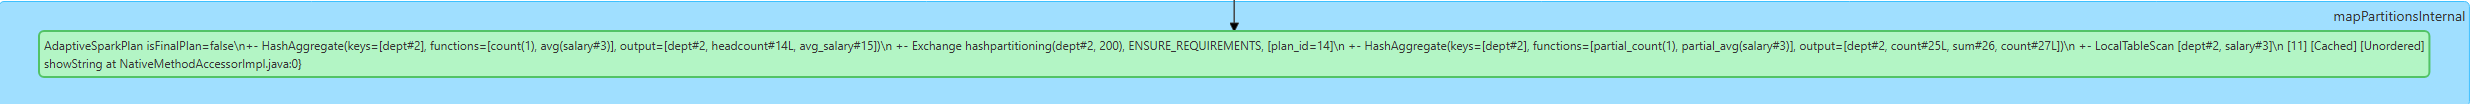


---

### What `mapPartitionsInternal` actually means

`mapPartitionsInternal` is not a new SQL operator. It is the Spark execution engine's partition-level wrapper. It means:

- "Run a function for each partition"
- That function is the physical plan inside the partition
- The inner `AdaptiveSparkPlan` is the actual compiled operator tree

So the block you saw is just Spark saying: "For each partition, run this adaptive aggregation plan." The `AdaptiveSparkPlan` is what lets AQE change the plan once it knows actual sizes.

---

### Why the plan still shows Exchange / HashAggregate even though the result is cached

The plan still contains the standard aggregation shape because Spark preserves the logical structure of the query. But with AQE and the cache:

- the source becomes `InMemoryTableScan [11] [Cached]`
- the shuffle may be coalesced or skipped
- only the final aggregation work actually runs

That is why the plan looks like it has a full aggregation pipeline, but the runtime cost is small.

---
```

Reads cached result, completes aggregation for display 
Job 2
 ├── Stage 3 (SKIPPED)
 │    └── WholeStageCodegen (1) + Exchange
 └── Stage 4 (EXECUTED)
      ├── Exchange
      │    └── ShuffledRowRDD [8] [Unordered]
      ├── WholeStageCodegen (2)
      ├── MapPartitionsRDD [9] [Unordered]
      ├── mapPartitionsInternal
      ├── MapPartitionsRDD [10] [Unordered]
      └── mapPartitionsInternal (AdaptiveSparkPlan isFinalPlan=false)
           ├── HashAggregate (final)
           │    └── Exchange hashpartitioning(dept#2, 200)
           │         └── HashAggregate (partial)
           │              └── LocalTableScan [dept#2, salary#3]
           │                   └── [11] [Cached] [Unordered]
           └── InMemoryTableScan
                ├── MapPartitionsRDD [12] [Unordered]
                ├── MapPartitionsRDD [13] [Unordered]
                ├── MapPartitionsRDD [14] [Unordered]
                ├── WholeStageCodegen (1)
                │    ├── MapPartitionsRDD [15] [Unordered]
                │    └── mapPartitionsInternal
                └── MapPartitionsRDD [16] [Unordered]
```
This is another read path over the cached intermediate result:
Stage 4 is the final stage that reads the cached intermediate result and produces the final grouped rows for display. Here's what each component does:

Top-level components:
  - `Exchange with ShuffledRowRDD [8] [Unordered]`: Reads the shuffle output from Stage 0. This is the intermediate data that was written to disk/network during the shuffle.

  - `WholeStageCodegen (2)`: Second compiled operator block. This is a different set of operators than WholeStageCodegen (1) - likely handling the post-shuffle processing.

  - `MapPartitionsRDD [9] [Unordered]`: Processes data partition-by-partition after the shuffle read. The [Unordered] means partition order is not guaranteed.

  - `mapPartitionsInternal`: The partition-level execution wrapper. This runs the operator pipeline for each partition.

  - `MapPartitionsRDD [10] [Unordered]`: Another layer of partition-level processing.

Main aggregation block:
  - `mapPartitionsInternal (AdaptiveSparkPlan isFinalPlan=false)`: The core aggregation logic. AdaptiveSparkPlan isFinalPlan=false means Spark is still optimizing the physical plan.

    - `HashAggregate (final)`: Performs the final aggregation step, combining partial results from all partitions.

    - `Exchange hashpartitioning(dept#2, 200)`: Another shuffle boundary for the final aggregation (likely coalesced to fewer partitions by AQE).

    - `HashAggregate (partial)`: Performs partial aggregation per partition before the final shuffle.

    - `LocalTableScan [dept#2, salary#3]`: Reads the cached intermediate data.

      - `[11] [Cached] [Unordered]`: The actual cached result from Job 1.
Additional cached read path:

`InMemoryTableScan`: Reads the cached partitioned table directly from memory.

-   `MapPartitionsRDD [12] [Unordered]`: Processes cached partitions.
-   `MapPartitionsRDD [13] [Unordered]`: Another cached processing layer.
-   `MapPartitionsRDD [14] [Unordered]`: Third cached processing layer.
-   `WholeStageCodegen (1)`: First compiled block for cached data.
-   `MapPartitionsRDD [15] [Unordered]`: Cached partition processing.
-   `mapPartitionsInternal`: Cached partition execution wrapper.
-   `MapPartitionsRDD [16] [Unordered]`: Final cached processing layer.

### What Stage 4 produces:
The final output is the complete grouped result: 3 rows showing department headcount and average salary, ready for show() to display.

### Why so many layers?
-  AQE is still adapting the plan (isFinalPlan=false)
-  Multiple read paths over cached data for optimization
-  Partition-level processing at each stage
-  Final aggregation combining all partial results
-  This stage takes the cached intermediate data and produces the final user-visible result.

### Action 1: `dept_summary.count()` → Job 3, 4, and 5
```
Job 3
 └── Stage 5 (EXECUTED)
      ├── WholeStageCodegen (1)
      │    └── ParallelCollectionRDD [17]
      │    └── MapPartitionsRDD [18]
      ├── Exchange
      │   └── MapPartitionsRDD [19]
       
```

```
Job 4
 ├── Stage 6 (SKIPPED)
 │    └── WholeStageCodegen (1) + Exchange
 └── Stage 7 (EXECUTED)
      ├── AQEShuffleRead
      │    └── ShuffledRowRDD [20] [Unordered]
      ├── WholeStageCodegen (2)
      │   └── MapPartitionsRDD [21] [Unordered]
      ├── Exchange
      │    └──MapPartitionsRDD [22] [Unordered]

```
```
Job 5
 ├── Stage 8 (SKIPPED)
 │    └── WholeStageCodegen (1) + Exchange
 ├── Stage 9 (SKIPPED)
 │    └── AQEShuffleRead + WholeStageCodegen (2) + Exchange
 └── Stage 10 (EXECUTED)
      ├── Exchange
      │    └── ShuffledRowRDD [23] [Unordered]
      ├── WholeStageCodegen (3)
      │    └── MapPartitionsRDD [24] [Unordered]
      ├── mapPartitionsInternal
      │    └── MapPartitionsRDD [25] [Unordered]
```
### Summary: exact execution for your 28-line example


### RDD ID quick reference (for your specific execution)

When reading the job tree, RDD IDs [N] identify each intermediate result:

| RDD ID | Type | What it represents |
|--------|------|-------------------|
| `[5]` | ParallelCollectionRDD | Original 10-row dataset (createDataFrame) |
| `[6]` | MapPartitionsRDD | After filter + withColumn in groupBy setup |
| `[7]` | MapPartitionsRDD | Data ready to shuffle (pre-Exchange) |
| `[8]` | ShuffledRowRDD | Data after Exchange shuffle, grouped by dept |
| `[9]` | MapPartitionsRDD | Post-shuffle, before final aggregation |
| `[10]` | MapPartitionsRDD | Intermediate result in final-agg computation |
| `[11]` | InMemory (Cached) | **The final grouped result: 3 rows (eng, sales, hr) stored in memory** |
| `[12]–[16]` | MapPartitionsRDD | New RDDs created by Job 1 (same logical ops, fresh execution) |
| `[17]–[21]` | MapPartitionsRDD | New RDDs created by Job 2 |
| `[22]–[24]` | MapPartitionsRDD | New RDDs created by Job 3 |

**Why do Jobs 1, 2, 3 get new RDD IDs?**
Each job is an independent execution. Spark creates fresh RDD objects for the task DAG, even if they logically represent the same computation. However, they all read from the same `[11]` (the cache), so the actual computation is minimal.

---

### Why your .show() and .count() runs produced multiple jobs

In section 8, you wrote:
```python
dept_summary.cache()
dept_summary.show()         # ← ACTION 1: Job 0
n = dept_summary.count()    # ← ACTION 2: Job 1
```

Plus, you likely ran:
```python
dept_summary.unpersist()    # Just marks for release; not an action
dept_summary.explain(mode="extended")  # Prints plan, NOT an action
```

So why 4 jobs? Possibilities:
- You ran `.show()` and `.count()` multiple times (re-executed cells)
- There were other actions in earlier notebook cells (section 3, 7)
- The Spark UI accumulated jobs from the entire notebook run

Each **new call to an action** on the same DataFrame submits a **new job**, even if the underlying computation is cached.

---


In [ ]:
# Spark session stays alive for the UI — call spark.stop() when truly done
print("Notebook complete. Spark UI still available at http://localhost:4040")
print("Run spark.stop() in a new cell to shut down.")